In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


'3.11.2'

In [2]:
df = pd.read_csv("../dataset/anscombe.csv")

In [46]:
df.sample(20)

,dataset,x,y
6,I,6,7.24
35,IV,8,7.71
8,I,12,10.84
23,III,8,6.77
1,I,8,6.95
11,II,10,9.14
20,II,7,7.26
18,II,4,3.10
13,II,13,8.74
39,IV,8,5.25


In [4]:
df.describe()

,x,y
count,44.000000,44.000000
mean,9.000000,7.500682
std,3.198837,1.958925
min,4.000000,3.100000
25%,7.000000,6.117500
50%,8.000000,7.520000
75%,11.000000,8.747500
max,19.000000,12.740000


In [5]:
df.shape

(44, 3)

First Series

In [38]:
series_I = df[df["dataset"] == "I"]
print(series_I["x"].mean())
print(series_I["x"].var())
print(series_I["y"].mean())
print(series_I["y"].var())



9.0
11.0
7.500909090909093
4.127269090909091


In [29]:
correlation = series_I["x"].corr(series_I["y"])
correlation

np.float64(0.81642051634484)

In [34]:
slope, intercept = np.polyfit(series_I["x"], series_I["y"], 1)
print(slope)
print(intercept)

0.5000909090909098
3.000090909090908


Second Series

In [35]:
series_II = df[df["dataset"] == "II"]
series_II

,dataset,x,y
11,II,10,9.14
12,II,8,8.14
13,II,13,8.74
14,II,9,8.77
15,II,11,9.26
16,II,14,8.10
17,II,6,6.13
18,II,4,3.10
19,II,12,9.13
20,II,7,7.26


In [37]:
print(series_II["x"].mean())
print(series_II["x"].var())
print(series_II["y"].mean())
print(series_II["y"].var())

9.0
11.0
7.50090909090909
4.127629090909091


In [39]:
correlation = series_II["x"].corr(series_II["y"])
correlation

np.float64(0.8162365060002428)

In [41]:
slope, intercept = np.polyfit(series_II["x"], series_II["y"], 1)
print(slope)
print(intercept)

0.5000000000000003
3.00090909090909


Third Series

In [44]:
series_III = df[df["dataset"] == "III"]
print(series_III["x"].mean())
print(series_III["x"].var())
print(series_III["y"].mean())
print(series_III["y"].var())

9.0
11.0
7.5
4.12262


In [45]:
correlation = series_II["x"].corr(series_II["y"])
slope, intercept = np.polyfit(series_II["x"], series_II["y"], 1)
print(correlation)
print(slope)
print(intercept)

0.8162365060002428
0.5000000000000003
3.00090909090909


Fourth Series

In [48]:
series_IV = df[df["dataset"] == "IV"]
print(series_IV["x"].mean())
print(series_IV["x"].var())
print(series_IV["y"].mean())
print(series_IV["y"].var())

9.0
11.0
7.500909090909091
4.123249090909091


In [49]:
correlation = series_IV["x"].corr(series_IV["y"])
slope, intercept = np.polyfit(series_IV["x"], series_IV["y"], 1)
print(correlation)
print(slope)
print(intercept)

0.8165214368885028
0.49990909090909086
3.0017272727272744


Simplified Version of Computing mean , variance , correlation , slope and intercept for all series 
by using reusable function

In [50]:
series_I = df[df["dataset"] == "I"]
series_II = df[df["dataset"] == "II"]
series_III = df[df["dataset"] == "III"]
series_IV = df[df["dataset"] == "IV"]

In [56]:
def analyze_series(series):
   slope, intercept = np.polyfit(series["x"], series["y"], 1)
   results = { "dataset": series["dataset"].iloc[0], 
              "x_mean": series["x"].mean(), 
              "x_var": series["x"].var(), 
              "y_mean": series["y"].mean(), 
              "y_var": series["y"].var(), 
              "correlation": series["x"].corr(series["y"]), 
              "slope": slope,
              "intercept": intercept }
   return results

In [57]:
results = [
    analyze_series(series_I),
    analyze_series(series_II),
    analyze_series(series_III),
    analyze_series(series_IV)
]

In [59]:
stats = pd.DataFrame(results)
stats.round(2)

,dataset,x_mean,x_var,y_mean,y_var,correlation,slope,intercept
0,I,9.0,11.0,7.5,4.13,0.82,0.5,3.0
1,II,9.0,11.0,7.5,4.13,0.82,0.5,3.0
2,III,9.0,11.0,7.5,4.12,0.82,0.5,3.0
3,IV,9.0,11.0,7.5,4.12,0.82,0.5,3.0


Plotting To See

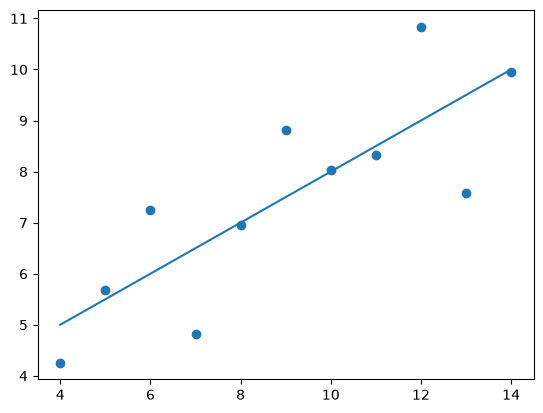

In [64]:
plt.scatter(series_I["x"], series_I["y"])
x_line = np.linspace(series_I["x"].min(), series_I["x"].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line)
plt.show()

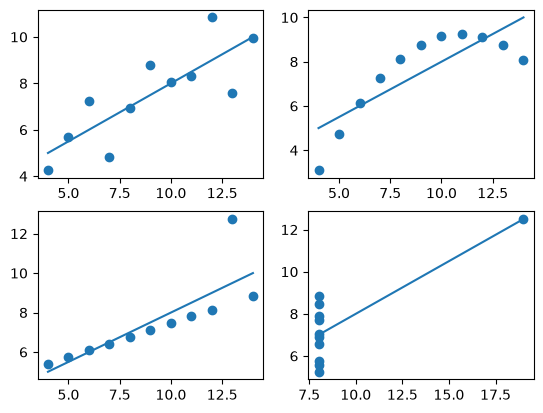

In [77]:
fig, axes = plt.subplots(2, 2)
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
ax1.scatter(series_I["x"], series_I["y"])
ax2.scatter(series_II["x"], series_II["y"])
ax3.scatter(series_III["x"], series_III["y"])
ax4.scatter(series_IV["x"], series_IV["y"])

slope, intercept = np.polyfit(series_I["x"], series_I["y"], 1)


x_line = np.linspace(series_I["x"].min(), series_I["x"].max(), 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line)

x_line = np.linspace(series_II["x"].min(), series_II["x"].max(), 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line)

x_line = np.linspace(series_III["x"].min(), series_III["x"].max(), 100)
y_line = slope * x_line + intercept
ax3.plot(x_line, y_line)

x_line = np.linspace(series_IV["x"].min(), series_IV["x"].max(), 100)
y_line = slope * x_line + intercept
ax4.plot(x_line, y_line)

plt.show()

# Summary of Plotting
statistical summary mayn't always true about what really the data look like so we have to check visually 

Points in series one forms approximately straight line,
Points in series two forms curved relationship so fitted line doesn't match,
Points in series three forms approximately straight line and one outlier affected fitted line,
Points in series four forms outlier relationship and the points actually forms nearly like vertical line but one point completely far away from them (strong outlier) and fitted line completely doesn't much